# ASCAT results analysis
## Plot chr22 deleted area cross all samples

In [1]:
import pandas as pd
import json
import matplotlib.pyplot as plt
import seaborn as sns
import os

/home/msanchezg/miniconda3/envs/rhabdoids/lib/python3.10/site-packages/scipy/__init__.py:155: UserWarning: A NumPy version >=1.18.5 and <1.26.0 is required for this version of SciPy (detected version 1.26.1
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [6]:
sjd_dict = json.load(open('sample_ids/sample_sjd_ids.json','rb'))
excluded_pts = ['pt2','pt10','pt16','pt20']
excluded_samples = [['pt9','t1'],['pt14','t2']]
sjd_dict = { pt:sjd_dict[pt] for pt in sjd_dict.keys() if pt not in excluded_pts}
sjd_dict['pt6'].pop('clone1')
sjd_dict['pt6'].pop('clone2')
sjd_dict['pt9'].pop('tumor1')
sjd_dict['pt14'].pop('tumor2')
sjd_dict['pt14'].pop('clone1')
sjd_dict['pt14'].pop('clone2')

print(len(sjd_dict.keys()))

target_dict = json.load(open('sample_ids/sample_target_ids.json','rb'))
target_dict = { pt:target_dict[pt] for pt in target_dict.keys() if 'normal' in target_dict[pt].keys()}

print(len(target_dict.keys()))

stjude_dict = json.load(open('sample_ids/sample_stjude_ids.json','rb'))
bad_quality_samples = ['SJ032047','SJ033133']
xenograft = ['SJ063832']
no_age_data = ['SJ014754']
excluded_samples =  bad_quality_samples + xenograft+ no_age_data
stjude_dict = { pt:stjude_dict[pt] for pt in stjude_dict.keys() if pt not in excluded_samples}

print(len(stjude_dict.keys()))

16
56
16


In [7]:
samples_dict = sjd_dict | target_dict | stjude_dict

In [8]:
print((len(samples_dict)))

88


In [ ]:
chrom = '22'

def create_dafarame_list (chrom):

    dataframes_list = []

    for pt in list(samples_dict.keys()):
        if pt.startswith('pt'):
            cohort = 'sjd'
        elif pt.startswith('PA'):
            cohort = 'target'
        elif pt.startswith('SJ'):
            cohort = 'stjude'
        else:
            print('Other cohort?', pt)
            
        tumors = [t for t in samples_dict[pt].keys() if 'tumor' in t]
        t = tumors[0]

        tumor_id = samples_dict[pt][t]
        normal_id = samples_dict[pt]['normal']
        sample_id = tumor_id +'_vs_'+normal_id
        
        #CN
        df = pd.read_csv('variant_calling/'+cohort+'_cohort/sarek_results/'+cohort+'_variant_calling/ascat/'+sample_id+'/'+sample_id+'.segments.txt',sep='\t')
        if sample_id == 'AX4944_vs_AX4897':
            for col in ['nMajor','nMinor']:
                df[col] = df[col].apply(lambda x: int(x-1) if x!=0 else x)
        sample_df = df[df['chr']==chrom].reset_index(drop=True)
        
        #correct CN in the samples with wrong WGD:
        if pt+'_'+t in ['pt5_tumor2','SJ030581_tumor1','PASVDP_tumor1']:
            for col in ['nMajor','nMinor']:
                sample_df[col] = sample_df[col].apply(lambda x: int(x-1) if x!=0 else x)

        def count_cnloh_area(row):
            cnloh = 0
            nmajor = row['nMajor']
            nminor = row['nMinor']
            if nmajor == 2 and nminor == 0:
                cnloh = cnloh +1
            return cnloh
        
        sample_df[sample_id] = sample_df.apply(lambda row: count_cnloh_area(row),axis=1)
        
        sample_df = sample_df[['startpos','endpos',sample_id]]
        
        dataframes_list.append(sample_df)
    
    return dataframes_list


In [10]:
import pandas as pd

# Data for table1: AX4916_vs_AX4896
data1 = {
    'startpos': [15513541, 23294152, 23427184, 24235780],
    'endpos': [23291655, 23424670, 24227169, 50757736],
    'value': [0, 1, 2, 1]
}
df1 = pd.DataFrame(data1)
df1.columns = ['startpos', 'endpos', 'AX4916_vs_AX4896']

# Data for table2: AX4912_vs_AX4894
data2 = {
    'startpos': [15513541, 22229175, 22381922, 24160539, 24466770],
    'endpos': [22229139, 22380190, 24150331, 24460361, 50757736],
    'value': [0, 1, 2, 1, 0]
}
df2 = pd.DataFrame(data2)
df2.columns = ['startpos', 'endpos', 'AX4912_vs_AX4894']

# Data for a third sample: AX5000_vs_AX4900
data3 = {
    'startpos': [22000000, 23000000, 24000000],
    'endpos': [23500000, 24500000, 55000000],
    'value': [5, 6, 7]
}
df3 = pd.DataFrame(data3)
df3.columns = ['startpos', 'endpos', 'AX5000_vs_AX4900']

def merge_genomic_intervals(df_a, df_b):
    """
    Helper function to merge two dataframes on overlapping genomic ranges.
    
    This function is designed to be used iteratively within a loop
    to merge multiple dataframes.
    """
    merged_rows = []
    
    # Get column names, excluding 'startpos' and 'endpos'
    cols_a = [col for col in df_a.columns if col not in ['startpos', 'endpos']]
    cols_b = [col for col in df_b.columns if col not in ['startpos', 'endpos']]
    
    # Iterate through each row in the first dataframe
    for _, row_a in df_a.iterrows():
        # Iterate through each row in the second dataframe
        for _, row_b in df_b.iterrows():
            
            # Check for overlap: an overlap exists if the start of one
            # is before the end of the other AND the end of the first
            # is after the start of the other.
            overlap_start = max(row_a['startpos'], row_b['startpos'])
            overlap_end = min(row_a['endpos'], row_b['endpos'])
            
            # If there is a valid overlap (start is less than end)
            if overlap_start < overlap_end:
                new_row = {
                    'startpos': overlap_start,
                    'endpos': overlap_end,
                }
                # Add columns from df_a
                for col in cols_a:
                    new_row[col] = row_a.get(col, None)
                # Add columns from df_b
                for col in cols_b:
                    new_row[col] = row_b.get(col, None)
                merged_rows.append(new_row)
    
    return pd.DataFrame(merged_rows)

def merge_multiple_genomic_tables(dataframes):
    """
    Merges a list of dataframes on overlapping genomic ranges in a loop.
    
    Args:
        dataframes (list): A list of pandas DataFrames to merge.
    
    Returns:
        pd.DataFrame: A single merged dataframe with all sample columns.
    """
    if not dataframes:
        return pd.DataFrame()
    
    # Initialize the merged dataframe with the first table
    merged_df = dataframes[0].copy()
    
    # Loop through the remaining dataframes and merge them one by one
    for i in range(1, len(dataframes)):
        df_to_merge = dataframes[i]
        merged_df = merge_genomic_intervals(merged_df, df_to_merge)
    
    # Sort the final dataframe by the new start position for clarity
    if not merged_df.empty:
        merged_df = merged_df.sort_values(by='startpos').reset_index(drop=True)
    
    return merged_df

# Perform the merge with the new, more flexible function
all_dataframes = [df1, df2, df3]
final_merged_table = merge_multiple_genomic_tables(all_dataframes)

# Print the final merged table to show the result
print("Final Merged Table with three samples:")
print(final_merged_table)

Final Merged Table with three samples:
    startpos    endpos  AX4916_vs_AX4896  AX4912_vs_AX4894  AX5000_vs_AX4900
0   22000000  22229139                 0                 0                 5
1   22229175  22380190                 0                 1                 5
2   22381922  23291655                 0                 2                 5
3   23000000  23291655                 0                 2                 6
4   23294152  23424670                 1                 2                 5
5   23294152  23424670                 1                 2                 6
6   23427184  23500000                 2                 2                 5
7   23427184  24150331                 2                 2                 6
8   24000000  24150331                 2                 2                 7
9   24160539  24227169                 2                 1                 6
10  24160539  24227169                 2                 1                 7
11  24235780  24460361               

In [11]:
chrom = '22'
dataframes_list =  create_dafarame_list (chrom)

In [12]:
final_merged_table = merge_multiple_genomic_tables(dataframes_list)
final_merged_table

,startpos,endpos,AX4912_vs_AX4894,AX4914_vs_AX4895,AX4916_vs_AX4896,AX4918_vs_AX4897,AX4945_vs_AX4898,AX4922_vs_AX4899,AX4930_vs_AX4900,AX4925_vs_AX4901,...,SJBT030997_D1_vs_SJBT030997_G1,SJBT031235_D1_vs_SJBT031235_G1,SJBT031605_D1_vs_SJBT031605_G1,SJBT031948_D2_vs_SJBT031948_G1,SJBT032346_D1_vs_SJBT032346_G1,SJBT032393_D1_vs_SJBT032393_G1,SJBT032417_D2_vs_SJBT032417_G1,SJBT033236_D2_vs_SJBT033236_G1,SJBT034089_D1_vs_SJBT034089_G1,SJBT034110_D2_vs_SJBT034110_G1
0,15513541,16090803,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
1,16093268,16112668,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
2,16113836,16692837,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
3,16693023,17229045,0,0,0,0,0,0,1,0,...,1,0,0,0,0,0,0,0,0,0
4,17231721,17360178,0,0,0,0,0,0,1,0,...,1,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
196,47920584,48260080,0,0,1,0,1,1,1,0,...,1,1,0,1,1,0,1,0,0,0
197,48262655,48338062,0,0,1,0,1,1,1,0,...,1,1,0,1,1,0,1,0,0,0
198,48342651,48426807,0,0,1,0,1,1,1,0,...,1,1,0,1,1,0,1,0,0,0
199,48427368,50018612,0,0,1,0,1,1,1,0,...,1,1,0,1,1,0,1,0,0,0


In [13]:
cols = final_merged_table.columns
cols = [c for c in cols if c not in ['startpos','endpos','total']]
print(len(cols))
cols

88


['AX4912_vs_AX4894',
 'AX4914_vs_AX4895',
 'AX4916_vs_AX4896',
 'AX4918_vs_AX4897',
 'AX4945_vs_AX4898',
 'AX4922_vs_AX4899',
 'AX4930_vs_AX4900',
 'AX4925_vs_AX4901',
 'AX4951_vs_AX4903',
 'AX4926_vs_AX4904',
 'AX4927_vs_AX4905',
 'AX4928_vs_AQ5174',
 'AX4923_vs_AX4906',
 'AX4932_vs_AX4908',
 'AX4933_vs_AX4909',
 'AX4935_vs_AX4910',
 'PABKLN-01A_vs_PABKLN-11A',
 'PADWRZ-01A_vs_PADWRZ-10A',
 'PADYZI-01A_vs_PADYZI-10A',
 'PAEHIP-01A_vs_PAEHIP-10A',
 'PAJLWM-01A_vs_PAJLWM-11A',
 'PAJMBW-01A_vs_PAJMBW-10A',
 'PAJMRB-01A_vs_PAJMRB-11A',
 'PAJNER-01A_vs_PAJNER-11A',
 'PAJNFP-01A_vs_PAJNFP-11A',
 'PAJNFZ-01A_vs_PAJNFZ-10A',
 'PAKHTL-01A_vs_PAKHTL-11A',
 'PAKLYZ-01A_vs_PAKLYZ-10A',
 'PAKTCT-01A_vs_PAKTCT-11A',
 'PARECB-01A_vs_PARECB-11A',
 'PAREWI-01A_vs_PAREWI-11A',
 'PARGRN-01A_vs_PARGRN-10A',
 'PARIRN-01A_vs_PARIRN-10A',
 'PARPFY-01A_vs_PARPFY-11A',
 'PARRCL-01A_vs_PARRCL-11A',
 'PARTKH-01A_vs_PARTKH-10A',
 'PARUGK-01A_vs_PARUGK-10A',
 'PARZBI-01A_vs_PARZBI-11A',
 'PARZRH-01A_vs_PARZRH-10A

In [14]:
final_merged_table['total'] = final_merged_table[cols].sum(axis=1)
final_merged_table

,startpos,endpos,AX4912_vs_AX4894,AX4914_vs_AX4895,AX4916_vs_AX4896,AX4918_vs_AX4897,AX4945_vs_AX4898,AX4922_vs_AX4899,AX4930_vs_AX4900,AX4925_vs_AX4901,...,SJBT031235_D1_vs_SJBT031235_G1,SJBT031605_D1_vs_SJBT031605_G1,SJBT031948_D2_vs_SJBT031948_G1,SJBT032346_D1_vs_SJBT032346_G1,SJBT032393_D1_vs_SJBT032393_G1,SJBT032417_D2_vs_SJBT032417_G1,SJBT033236_D2_vs_SJBT033236_G1,SJBT034089_D1_vs_SJBT034089_G1,SJBT034110_D2_vs_SJBT034110_G1,total
0,15513541,16090803,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,10
1,16093268,16112668,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,10
2,16113836,16692837,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,11
3,16693023,17229045,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,12
4,17231721,17360178,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
196,47920584,48260080,0,0,1,0,1,1,1,0,...,1,0,1,1,0,1,0,0,0,34
197,48262655,48338062,0,0,1,0,1,1,1,0,...,1,0,1,1,0,1,0,0,0,34
198,48342651,48426807,0,0,1,0,1,1,1,0,...,1,0,1,1,0,1,0,0,0,34
199,48427368,50018612,0,0,1,0,1,1,1,0,...,1,0,1,1,0,1,0,0,0,34


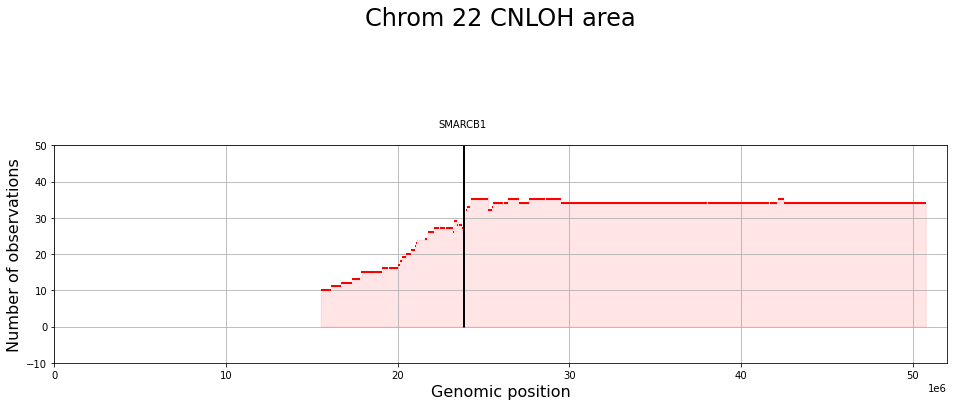

In [15]:
plt.figure(figsize=(16,4))
xmin = final_merged_table['startpos'].tolist()
xmax = final_merged_table['endpos'].tolist()
y = final_merged_table['total'].tolist()
y = [n+0.1 for n in y]
# plt.hlines(0.0, xmin[0], xmax[-1], linewidth=2, linestyle='dashed')
# plt.hlines(1.05, xmin[0], xmax[-1], linewidth=1, linestyle='dashed')
# plt.hlines(2.05, xmin[0], xmax[-1], linewidth=1, linestyle='dashed')
plt.hlines(y, xmin, xmax, linewidth=2, color='r')
# y = final_merged_table['nMinor'].tolist()

smarcb1_range = [23786931, 23838009]
x1 = smarcb1_range[0]
x2 = smarcb1_range[1]

plt.vlines(x1, 0, 50, linewidth=1,color='k')
plt.vlines(x2, 0, 50, linewidth=1,color='k')

plt.text(x=x1, y=55, s='SMARCB1',ha='center')

# plt.hlines(y, xmin, xmax, linewidth=5, color='r')

# Get x and y data for the plot
xmin = final_merged_table['startpos'].tolist()
xmax = final_merged_table['endpos'].tolist()
y = final_merged_table['total'].tolist()

# Add a colored area under the curve using fill_between
plt.fill_between(
    x=[val for pair in zip(xmin, xmax) for val in pair], # creates [start1, end1, start2, end2, ...]
    y1=[val for pair in zip(y, y) for val in pair], # repeats each y value to match the x list
    y2=0,
    color='red',
    alpha=0.1
)

plt.xlim(0,52000000)
plt.ticklabel_format(axis='x', style='sci', scilimits=(6,6))
# plt.ylim(-120,10)

# plt.yticks(ticks=list(range(0,-10,10)),labels=list(range(0,-10,50)))

plt.ylim(-10,50)
plt.ylabel('Number of observations',size=16)
plt.xlabel('Genomic position',size=16)
plt.title('Chrom 22 CNLOH area',size=24,pad=120)
plt.grid(visible=True)
plt.savefig('plots/chrom22_CNLOH_area.svg', bbox_inches='tight',format='svg')
plt.show()

## Chromosome 19

In [16]:
chrom = '19'
dataframes_list =  create_dafarame_list (chrom)

In [17]:
final_merged_table = merge_multiple_genomic_tables(dataframes_list)
final_merged_table

,startpos,endpos,AX4912_vs_AX4894,AX4914_vs_AX4895,AX4916_vs_AX4896,AX4918_vs_AX4897,AX4945_vs_AX4898,AX4922_vs_AX4899,AX4930_vs_AX4900,AX4925_vs_AX4901,...,SJBT030997_D1_vs_SJBT030997_G1,SJBT031235_D1_vs_SJBT031235_G1,SJBT031605_D1_vs_SJBT031605_G1,SJBT031948_D2_vs_SJBT031948_G1,SJBT032346_D1_vs_SJBT032346_G1,SJBT032393_D1_vs_SJBT032393_G1,SJBT032417_D2_vs_SJBT032417_G1,SJBT033236_D2_vs_SJBT033236_G1,SJBT034089_D1_vs_SJBT034089_G1,SJBT034110_D2_vs_SJBT034110_G1
0,274479,12968375,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,12979076,15620515,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,15620655,15669231,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,15669259,15721616,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,15722029,24175770,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,24184823,24191617,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6,24192055,24202893,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7,24203050,24238563,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
8,24238573,24313990,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9,24314016,27291322,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [18]:
cols = final_merged_table.columns
cols = [c for c in cols if c not in ['startpos','endpos','total']]
print(len(cols))
cols

88


['AX4912_vs_AX4894',
 'AX4914_vs_AX4895',
 'AX4916_vs_AX4896',
 'AX4918_vs_AX4897',
 'AX4945_vs_AX4898',
 'AX4922_vs_AX4899',
 'AX4930_vs_AX4900',
 'AX4925_vs_AX4901',
 'AX4951_vs_AX4903',
 'AX4926_vs_AX4904',
 'AX4927_vs_AX4905',
 'AX4928_vs_AQ5174',
 'AX4923_vs_AX4906',
 'AX4932_vs_AX4908',
 'AX4933_vs_AX4909',
 'AX4935_vs_AX4910',
 'PABKLN-01A_vs_PABKLN-11A',
 'PADWRZ-01A_vs_PADWRZ-10A',
 'PADYZI-01A_vs_PADYZI-10A',
 'PAEHIP-01A_vs_PAEHIP-10A',
 'PAJLWM-01A_vs_PAJLWM-11A',
 'PAJMBW-01A_vs_PAJMBW-10A',
 'PAJMRB-01A_vs_PAJMRB-11A',
 'PAJNER-01A_vs_PAJNER-11A',
 'PAJNFP-01A_vs_PAJNFP-11A',
 'PAJNFZ-01A_vs_PAJNFZ-10A',
 'PAKHTL-01A_vs_PAKHTL-11A',
 'PAKLYZ-01A_vs_PAKLYZ-10A',
 'PAKTCT-01A_vs_PAKTCT-11A',
 'PARECB-01A_vs_PARECB-11A',
 'PAREWI-01A_vs_PAREWI-11A',
 'PARGRN-01A_vs_PARGRN-10A',
 'PARIRN-01A_vs_PARIRN-10A',
 'PARPFY-01A_vs_PARPFY-11A',
 'PARRCL-01A_vs_PARRCL-11A',
 'PARTKH-01A_vs_PARTKH-10A',
 'PARUGK-01A_vs_PARUGK-10A',
 'PARZBI-01A_vs_PARZBI-11A',
 'PARZRH-01A_vs_PARZRH-10A

In [19]:
final_merged_table['total'] = final_merged_table[cols].sum(axis=1)
final_merged_table

,startpos,endpos,AX4912_vs_AX4894,AX4914_vs_AX4895,AX4916_vs_AX4896,AX4918_vs_AX4897,AX4945_vs_AX4898,AX4922_vs_AX4899,AX4930_vs_AX4900,AX4925_vs_AX4901,...,SJBT031235_D1_vs_SJBT031235_G1,SJBT031605_D1_vs_SJBT031605_G1,SJBT031948_D2_vs_SJBT031948_G1,SJBT032346_D1_vs_SJBT032346_G1,SJBT032393_D1_vs_SJBT032393_G1,SJBT032417_D2_vs_SJBT032417_G1,SJBT033236_D2_vs_SJBT033236_G1,SJBT034089_D1_vs_SJBT034089_G1,SJBT034110_D2_vs_SJBT034110_G1,total
0,274479,12968375,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,2
1,12979076,15620515,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
2,15620655,15669231,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,15669259,15721616,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
4,15722029,24175770,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,24184823,24191617,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6,24192055,24202893,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7,24203050,24238563,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
8,24238573,24313990,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9,24314016,27291322,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


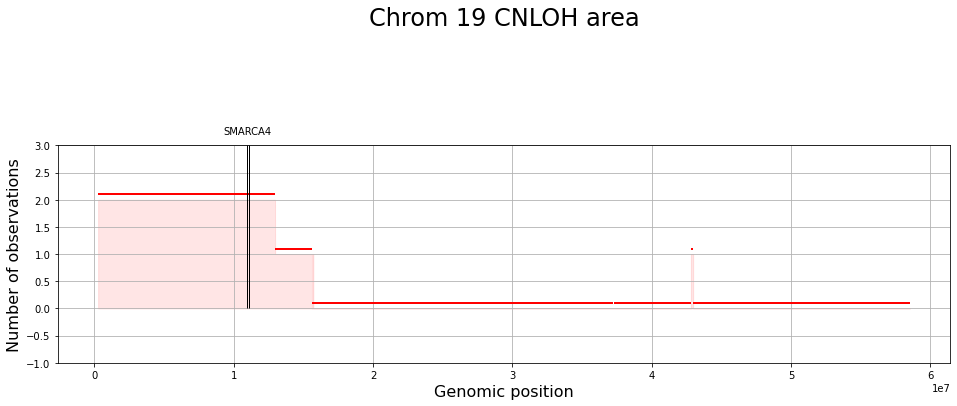

In [20]:
plt.figure(figsize=(16,4))
xmin = final_merged_table['startpos'].tolist()
xmax = final_merged_table['endpos'].tolist()
y = final_merged_table['total'].tolist()
y = [n+0.1 for n in y]
# plt.hlines(0.0, xmin[0], xmax[-1], linewidth=2, linestyle='dashed')
# plt.hlines(1.05, xmin[0], xmax[-1], linewidth=1, linestyle='dashed')
# plt.hlines(2.05, xmin[0], xmax[-1], linewidth=1, linestyle='dashed')
plt.hlines(y, xmin, xmax, linewidth=2, color='r')
# y = final_merged_table['nMinor'].tolist()
# plt.hlines(y, xmin, xmax, linewidth=5, color='r')

# Get x and y data for the plot
xmin = final_merged_table['startpos'].tolist()
xmax = final_merged_table['endpos'].tolist()
y = final_merged_table['total'].tolist()

smarca4_range = [10960932, 11079426]
x1 = smarca4_range[0]
x2 = smarca4_range[1]

plt.vlines(x1, 0, 3, linewidth=1,color='k')
plt.vlines(x2, 0, 3, linewidth=1,color='k')

plt.text(x=x1, y=3.2, s='SMARCA4',ha='center')

# Add a colored area under the curve using fill_between
plt.fill_between(
    x=[val for pair in zip(xmin, xmax) for val in pair], # creates [start1, end1, start2, end2, ...]
    y1=[val for pair in zip(y, y) for val in pair], # repeats each y value to match the x list
    y2=0,
    color='red',
    alpha=0.1
)

plt.ylim(-1,3)
plt.ylabel('Number of observations',size=16)
plt.xlabel('Genomic position',size=16)
plt.title('Chrom 19 CNLOH area',size=24,pad=120)
plt.grid(visible=True)
plt.savefig('plots/chrom19_CNLOH_area.svg', bbox_inches='tight',format='svg')
plt.show()